# Mouse Dynamics — Análise dos Outputs

Notebook para análise dos resultados dos experimentos: parâmetros Optuna por classificador, scatter de usuários entre pares de classificadores e boxplot de acurácia balanceada por classificador.

## 0. Setup

In [1]:
import json
import glob
import os
import itertools
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

# Ajuste este caminho se necessário
OUTPUTS_DIR = Path('../outputs')

## 1. Carregamento dos dados

In [2]:
records = []

for path in sorted(OUTPUTS_DIR.glob('**/*.json')):
    with open(path) as f:
        run = json.load(f)

    base = {
        'run_id':      run['run_id'],
        'classifier':  run['classifier'],
        'dataset':     run['dataset'],
        'window_size': run['preprocessor_window_size'],
    }

    for user in run['user_results']:
        records.append({
            **base,
            'user_id':        user['user_id'],
            'balanced_score': user['balanced_score'],
            'score':          user['score'],
            'f1_macro':       user['f1_macro'],
            'best_params':    user['best_params'],
        })

df = pd.DataFrame(records)
print(f"Total de registros: {len(df)}")
print(f"Classificadores : {sorted(df['classifier'].unique())}")
print(f"Datasets        : {sorted(df['dataset'].unique())}")
print(f"Window sizes    : {sorted(df['window_size'].unique())}")
df.head()

Total de registros: 1166
Classificadores : ['knn', 'mlp', 'random-forest']
Datasets        : ['balabit', 'bogazici', 'minecraft']
Window sizes    : [np.int64(10), np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(250)]


,run_id,classifier,dataset,window_size,user_id,balanced_score,score,f1_macro,best_params
0,085dcef5,random-forest,balabit,150,21,0.667163,0.608586,0.608164,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
1,085dcef5,random-forest,balabit,150,9,0.987442,0.987440,0.982497,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
2,085dcef5,random-forest,balabit,150,12,0.618592,0.579744,0.566160,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
3,085dcef5,random-forest,balabit,150,35,0.564105,0.615819,0.564997,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
4,085dcef5,random-forest,balabit,150,23,0.651456,0.651210,0.650013,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."


---
## 2. Melhores parâmetros Optuna por classificador

Para cada classificador, seleciona o run com maior `balanced_score` médio (run-level) e exibe os parâmetros de cada usuário desse run.

In [3]:
# Média de balanced_score por run
run_means = (
    df.groupby(['classifier', 'dataset', 'window_size', 'run_id'])['balanced_score']
    .mean()
    .reset_index(name='mean_balanced_score')
)

# Melhor run por classificador
best_runs = (
    run_means
    .sort_values('mean_balanced_score', ascending=False)
    .groupby('classifier')
    .first()
    .reset_index()
)

print("Melhor run por classificador:")
display(best_runs[['classifier', 'dataset', 'window_size', 'run_id', 'mean_balanced_score']])

Melhor run por classificador:


,classifier,dataset,window_size,run_id,mean_balanced_score
0,knn,minecraft,250,ddea69fc,0.753827
1,mlp,bogazici,150,3351238c,0.710641
2,random-forest,minecraft,250,7d7ff404,0.762260


Para cada dataset, seleciona o run com maior `balanced_score` médio (run-level) e exibe os parâmetros de cada usuário desse run.

In [4]:
# Melhor run por dataset
best_runs = (
    run_means
    .sort_values('mean_balanced_score', ascending=False)
    .groupby('dataset')
    .first()
    .reset_index()
)

print("Melhor run por dataset:")
display(best_runs[['dataset', 'classifier', 'window_size', 'run_id', 'mean_balanced_score']])

Melhor run por dataset:


,dataset,classifier,window_size,run_id,mean_balanced_score
0,balabit,random-forest,250,ee19a981,0.729432
1,bogazici,random-forest,250,e5bac9d7,0.710723
2,minecraft,random-forest,250,7d7ff404,0.762260


Para cada `window_size`, seleciona o run com maior `balanced_score` médio (run-level) e exibe os parâmetros de cada usuário desse run.

In [5]:
# Melhor run por window_size
best_runs = (
    run_means
    .sort_values('mean_balanced_score', ascending=False)
    .groupby('window_size')
    .first()
    .reset_index()
)

print("Melhor run por window_size:")
display(best_runs[['window_size', 'dataset', 'classifier', 'run_id', 'mean_balanced_score']])

Melhor run por window_size:


,window_size,dataset,classifier,run_id,mean_balanced_score
0,10,balabit,random-forest,36f7f70c,0.699876
1,50,balabit,random-forest,c283e064,0.717032
2,100,balabit,random-forest,c5d17e74,0.720295
3,150,balabit,random-forest,085dcef5,0.725756
4,200,minecraft,random-forest,b5a83277,0.735848
5,250,minecraft,random-forest,7d7ff404,0.762260


---
## 3. Scatter de usuários: classificador X vs classificador Y

Cada ponto é um usuário; o eixo X é o `balanced_score` de um classificador e o eixo Y de outro. Exibe todos os pares possíveis, por dataset.

In [6]:
# Para o scatter, usa o melhor run de cada (classifier, dataset) combinação
best_per_clf_dataset = (
    run_means
    .sort_values('mean_balanced_score', ascending=False)
    .groupby(['classifier', 'dataset'])
    .first()
    .reset_index()
)

print("Run selecionado por (classifier, dataset):")
display(best_per_clf_dataset[['classifier', 'dataset', 'window_size', 'run_id', 'mean_balanced_score']])

Run selecionado por (classifier, dataset):


,classifier,dataset,window_size,run_id,mean_balanced_score
0,knn,balabit,50,c55275fb,0.649203
1,knn,bogazici,250,e947b410,0.647368
2,knn,minecraft,250,ddea69fc,0.753827
3,mlp,balabit,150,95a9bba2,0.678722
4,mlp,bogazici,150,3351238c,0.710641
5,mlp,minecraft,10,8b7b7150,0.611624
6,random-forest,balabit,250,ee19a981,0.729432
7,random-forest,bogazici,250,e5bac9d7,0.710723
8,random-forest,minecraft,250,7d7ff404,0.762260


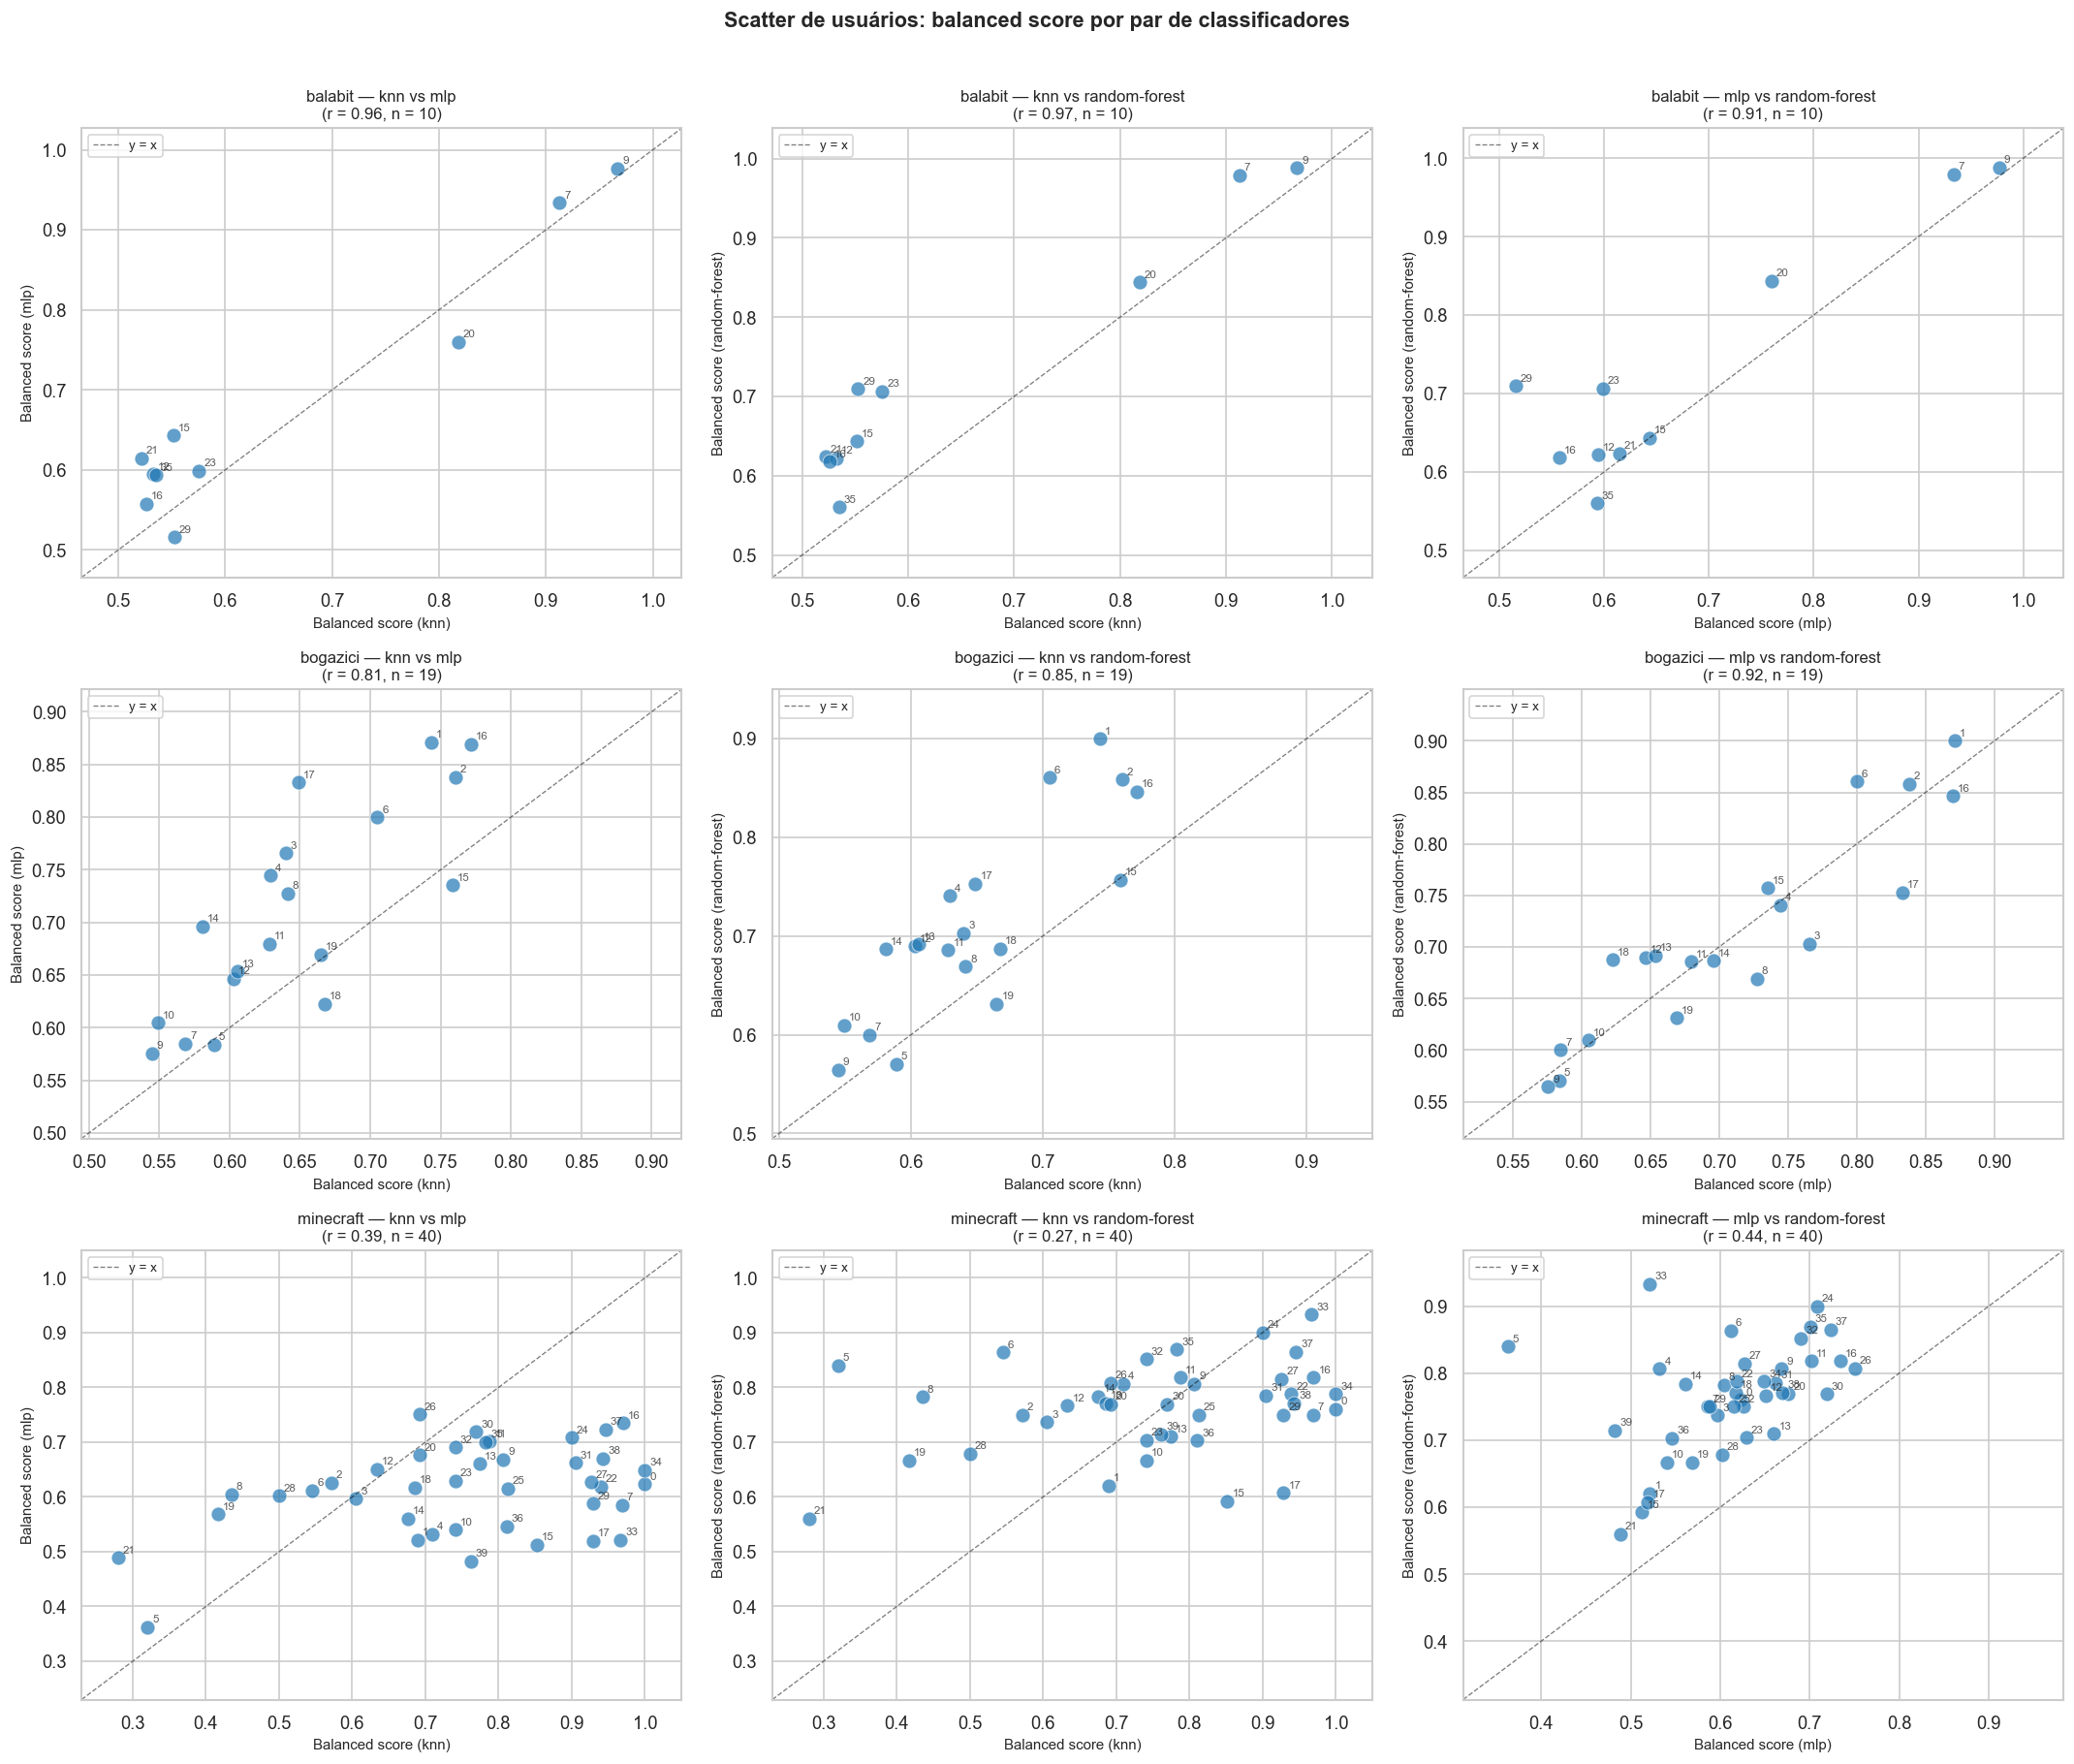

In [7]:
def get_best_run_scores(classifier, dataset, best_runs_df, full_df):
    """Retorna Series user_id -> balanced_score do melhor run."""
    row = best_runs_df[(best_runs_df['classifier'] == classifier) &
                       (best_runs_df['dataset']    == dataset)]
    if row.empty:
        return None
    rid = row.iloc[0]['run_id']
    sub = full_df[(full_df['classifier'] == classifier) &
                  (full_df['run_id']     == rid)]
    return sub.set_index('user_id')['balanced_score']


classifiers = sorted(df['classifier'].unique())
datasets    = sorted(df['dataset'].unique())
pairs       = list(itertools.combinations(classifiers, 2))

fig, axes = plt.subplots(
    len(datasets), len(pairs),
    figsize=(6 * len(pairs), 5 * len(datasets)),
    squeeze=False
)

for row_idx, dataset in enumerate(datasets):
    for col_idx, (clf_x, clf_y) in enumerate(pairs):
        ax = axes[row_idx][col_idx]

        scores_x = get_best_run_scores(clf_x, dataset, best_per_clf_dataset, df)
        scores_y = get_best_run_scores(clf_y, dataset, best_per_clf_dataset, df)

        if scores_x is None or scores_y is None:
            ax.set_visible(False)
            continue

        common_users = scores_x.index.intersection(scores_y.index)
        x = scores_x.loc[common_users].values
        y = scores_y.loc[common_users].values

        ax.scatter(x, y, alpha=0.7, edgecolors='white', linewidth=0.5, s=80)

        # Linha de referência y = x
        lim = (min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05)
        ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5, label='y = x')
        ax.set_xlim(lim)
        ax.set_ylim(lim)

        # Anota cada ponto com user_id
        for uid, xi, yi in zip(common_users, x, y):
            ax.annotate(uid, (xi, yi), fontsize=7, ha='left',
                        xytext=(3, 3), textcoords='offset points', alpha=0.75)

        corr = np.corrcoef(x, y)[0, 1]
        ax.set_title(f"{dataset} — {clf_x} vs {clf_y}\n(r = {corr:.2f}, n = {len(common_users)})",
                     fontsize=10)
        ax.set_xlabel(f"Balanced score ({clf_x})", fontsize=9)
        ax.set_ylabel(f"Balanced score ({clf_y})", fontsize=9)
        ax.legend(fontsize=8)

plt.suptitle("Scatter de usuários: balanced score por par de classificadores",
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_classifiers.png', bbox_inches='tight')
plt.show()

---
## 4.1. Boxplot de balanced_score de usuários por classificador

Mostra a distribuição de `balanced_score` a nível de usuário para cada classificador, separado por dataset.

In [8]:
# Usa o melhor run de cada (classifier, dataset)
best_run_ids = (
    best_per_clf_dataset
    .set_index(['classifier', 'dataset'])['run_id']
    .to_dict()
)

def is_best_run(row):
    key = (row['classifier'], row['dataset'])
    return best_run_ids.get(key) == row['run_id']

df_best = df[df.apply(is_best_run, axis=1)].copy()
print(f"Registros no melhor run por (clf, dataset): {len(df_best)}")

Registros no melhor run por (clf, dataset): 207


e:\ufabc\ic\mouse-dynamics\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
e:\ufabc\ic\mouse-dynamics\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
e:\ufabc\ic\mouse-dynamics\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


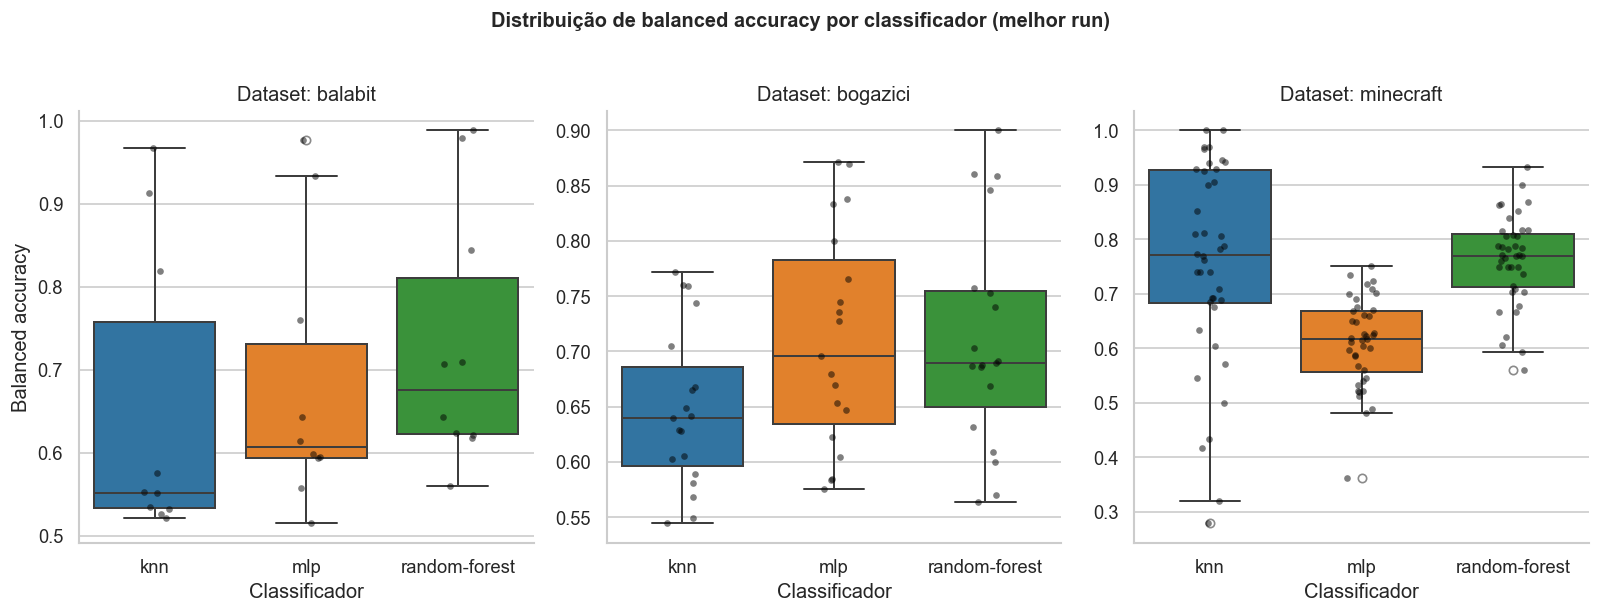

In [9]:
g = sns.FacetGrid(
    df_best,
    col='dataset',
    height=5,
    aspect=0.9,
    sharey=False,
)

g.map_dataframe(
    sns.boxplot,
    x='classifier',
    y='balanced_score',
    order=classifiers,
    palette='tab10',
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=5, alpha=0.6),
)

g.map_dataframe(
    sns.stripplot,
    x='classifier',
    y='balanced_score',
    order=classifiers,
    color='black',
    alpha=0.5,
    size=4,
    jitter=True,
)

g.set_axis_labels("Classificador", "Balanced accuracy")
g.set_titles(col_template="Dataset: {col_name}")
g.figure.suptitle("Distribuição de balanced accuracy por classificador (melhor run)",
                  fontsize=12, fontweight='bold', y=1.02)
g.tight_layout()
g.savefig('boxplot_classifiers.png', bbox_inches='tight')
plt.show()

In [10]:
# Estatísticas descritivas
stats = (
    df_best
    .groupby(['dataset', 'classifier'])['balanced_score']
    .describe()
    .round(4)
)
display(stats)

count    mean     std     min     25%     50%  \
dataset   classifier                                                     
balabit   knn             10.0  0.6492  0.1769  0.5218  0.5330  0.5519   
          mlp             10.0  0.6787  0.1591  0.5156  0.5937  0.6067   
          random-forest   10.0  0.7294  0.1544  0.5601  0.6224  0.6750   
bogazici  knn             19.0  0.6474  0.0717  0.5449  0.5960  0.6400   
          mlp             19.0  0.7106  0.0985  0.5758  0.6346  0.6961   
          random-forest   19.0  0.7107  0.0993  0.5642  0.6501  0.6898   
minecraft knn             40.0  0.7538  0.1863  0.2800  0.6832  0.7717   
          mlp             40.0  0.6116  0.0816  0.3627  0.5570  0.6178   
          random-forest   40.0  0.7623  0.0824  0.5600  0.7131  0.7703   

                            75%     max  
dataset   classifier                     
balabit   knn            0.7575  0.9671  
          mlp            0.7305  0.9768  
          random-forest  0.8104  0.9881  
bogazici  knn            0.6863  0.7714  
          mlp            0.7828  0.8713  
          random-forest  0.7550  0.8999  
minecraft knn            0.9266  1.0000  
          mlp            0.6691  0.7504  
          random-forest  0.8095  0.9333

### 4.2 Boxplot de balanced_score por window_size (por classificador e dataset)

Usa **todos** os runs disponíveis para cada window_size, mostrando a distribuição de `balanced_score` entre usuários em função do tamanho da janela.

C:\Users\matmo\AppData\Local\Temp\ipykernel_21744\3808078469.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\matmo\AppData\Local\Temp\ipykernel_21744\3808078469.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\matmo\AppData\Local\Temp\ipykernel_21744\3808078469.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\matmo\AppData\Local\Temp\ipykernel_21744\3808078469.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

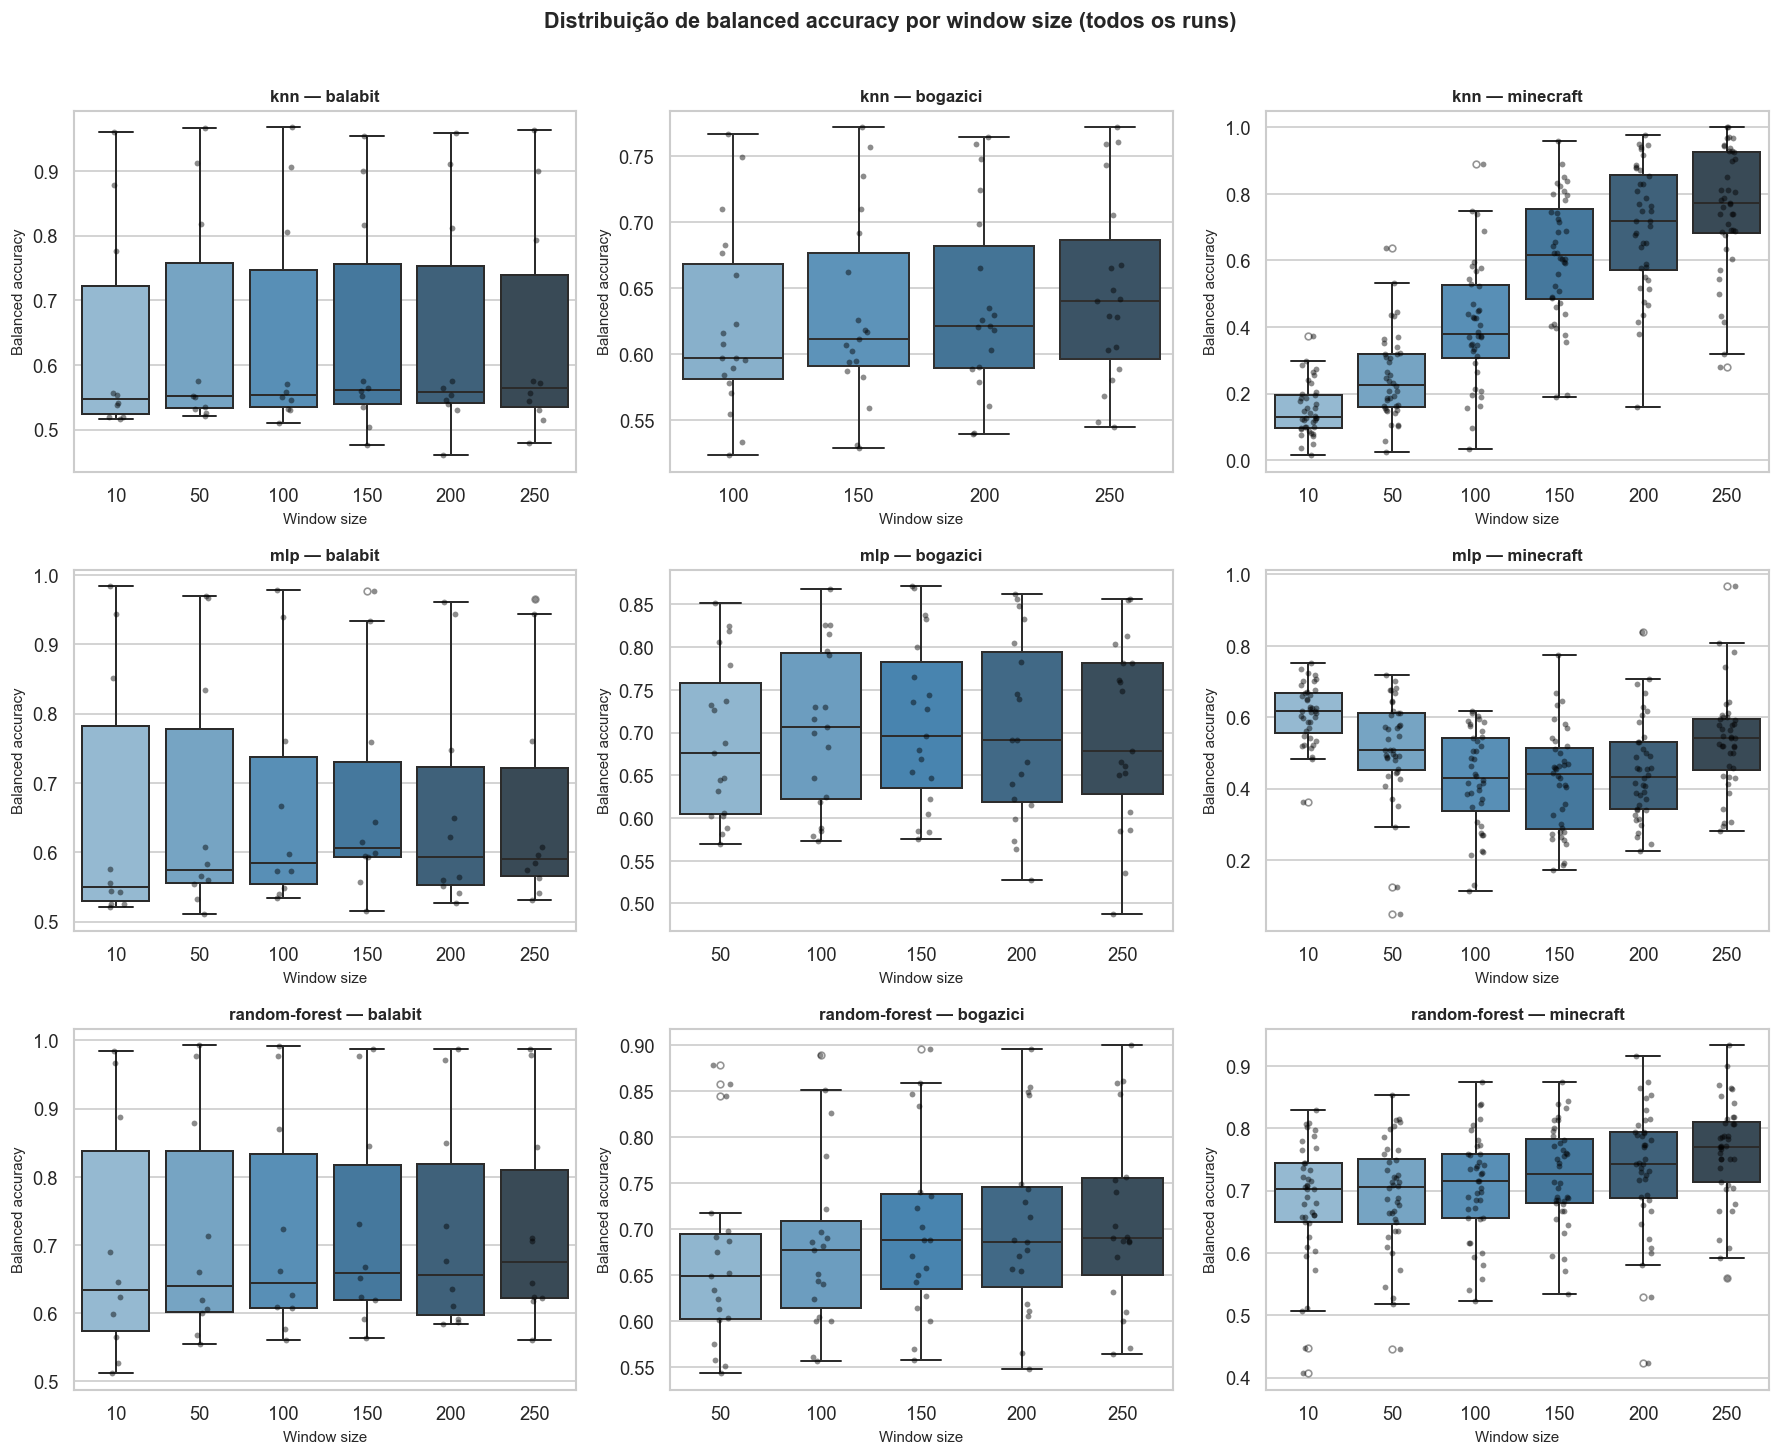

In [16]:
classifiers_ws = sorted(df['classifier'].unique())
datasets_ws    = sorted(df['dataset'].unique())

n_rows_ws = len(classifiers_ws)
n_cols_ws = len(datasets_ws)

fig, axes = plt.subplots(
    n_rows_ws, n_cols_ws,
    figsize=(5 * n_cols_ws, 4 * n_rows_ws),
    squeeze=False,
    sharey=False,
)

window_order = sorted(df['window_size'].unique())

for row_idx, clf in enumerate(classifiers_ws):
    for col_idx, dataset in enumerate(datasets_ws):
        ax = axes[row_idx][col_idx]

        sub = df[(df['classifier'] == clf) & (df['dataset'] == dataset)]

        if sub.empty:
            ax.set_visible(False)
            continue

        ws_present = sorted(sub['window_size'].unique())

        sns.boxplot(
            data=sub,
            x='window_size',
            y='balanced_score',
            order=ws_present,
            palette='Blues_d',
            linewidth=1.2,
            flierprops=dict(marker='o', markersize=4, alpha=0.5),
            ax=ax,
        )
        sns.stripplot(
            data=sub,
            x='window_size',
            y='balanced_score',
            order=ws_present,
            color='black',
            alpha=0.45,
            size=3.5,
            jitter=True,
            ax=ax,
        )

        ax.set_title(f"{clf} — {dataset}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Window size", fontsize=9)
        ax.set_ylabel("Balanced accuracy", fontsize=9)
        ax.tick_params(axis='x', rotation=0)

plt.suptitle(
    "Distribuição de balanced accuracy por window size (todos os runs)",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('boxplot_window_size.png', bbox_inches='tight')
plt.show()

---
## 5. Boxplot global: todos os runs (todas as window sizes)

Variante que usa **todos** os runs disponíveis, não apenas o melhor. Útil para ver o impacto da variação de hiperparâmetros.

e:\ufabc\ic\mouse-dynamics\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
e:\ufabc\ic\mouse-dynamics\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
e:\ufabc\ic\mouse-dynamics\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


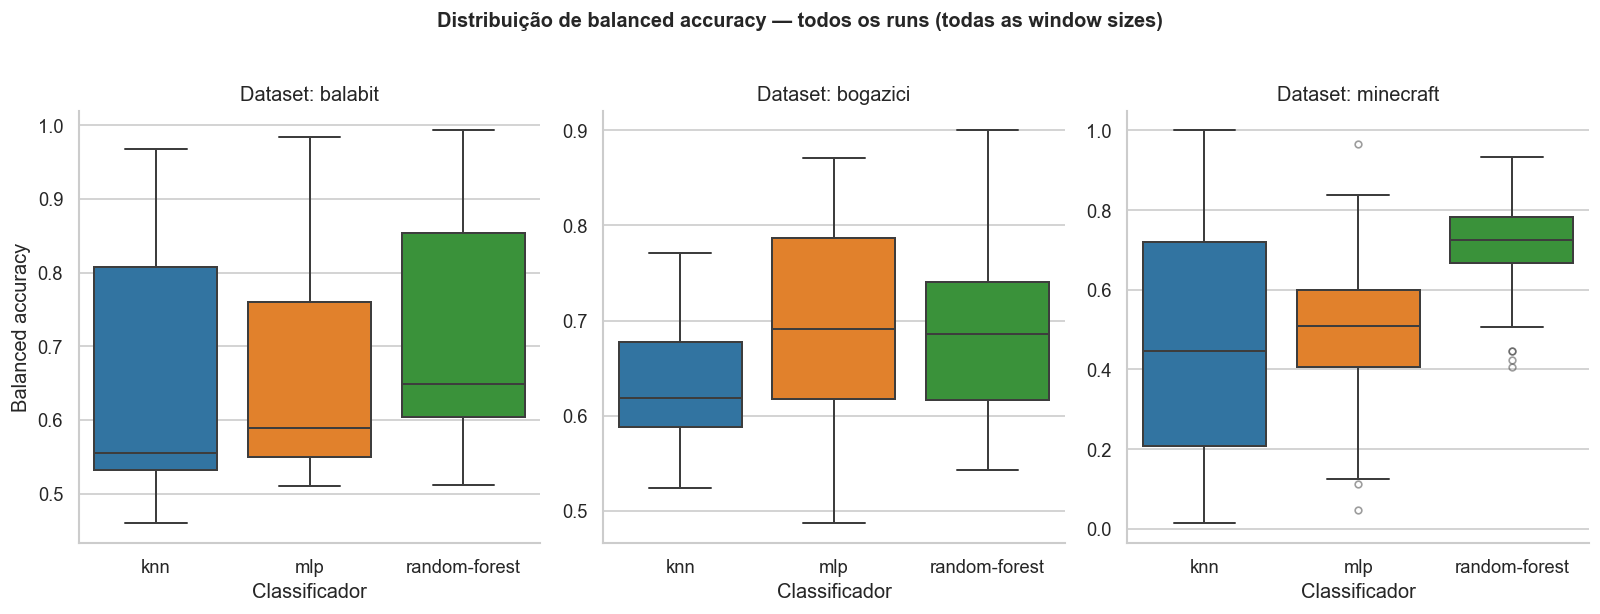

In [11]:
g2 = sns.FacetGrid(
    df,
    col='dataset',
    height=5,
    aspect=0.9,
    sharey=False,
)

g2.map_dataframe(
    sns.boxplot,
    x='classifier',
    y='balanced_score',
    order=classifiers,
    palette='tab10',
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
)

g2.set_axis_labels("Classificador", "Balanced accuracy")
g2.set_titles(col_template="Dataset: {col_name}")
g2.figure.suptitle(
    "Distribuição de balanced accuracy — todos os runs (todas as window sizes)",
    fontsize=12, fontweight='bold', y=1.02
)
g2.tight_layout()
g2.savefig('boxplot_classifiers_all_runs.png', bbox_inches='tight')
plt.show()

-------------------

In [12]:
# Melhor run por (classifier, dataset, window_size)
best_per_clf_ds_ws = (
    run_means
    .sort_values('mean_balanced_score', ascending=False)
    .groupby(['classifier', 'dataset', 'window_size'])
    .first()
    .reset_index()[['classifier', 'dataset', 'window_size', 'run_id', 'mean_balanced_score']]
)

# Filtra df apenas para esses run_ids
df_ws = df.merge(
    best_per_clf_ds_ws[['classifier', 'dataset', 'window_size', 'run_id']],
    on=['classifier', 'dataset', 'window_size', 'run_id'],
    how='inner'
)

print(f"Registros no melhor run por (clf, dataset, window_size): {len(df_ws)}")
print(f"Window sizes disponíveis: {sorted(df_ws['window_size'].unique())}")
df_ws[['classifier', 'dataset', 'window_size', 'user_id', 'balanced_score']].head(10)

Registros no melhor run por (clf, dataset, window_size): 1166
Window sizes disponíveis: [np.int64(10), np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(250)]


,classifier,dataset,window_size,user_id,balanced_score
0,random-forest,balabit,150,21,0.667163
1,random-forest,balabit,150,9,0.987442
2,random-forest,balabit,150,12,0.618592
3,random-forest,balabit,150,35,0.564105
4,random-forest,balabit,150,23,0.651456
5,random-forest,balabit,150,29,0.730983
6,random-forest,balabit,150,16,0.591001
7,random-forest,balabit,150,15,0.623539
8,random-forest,balabit,150,20,0.845786
9,random-forest,balabit,150,7,0.977497


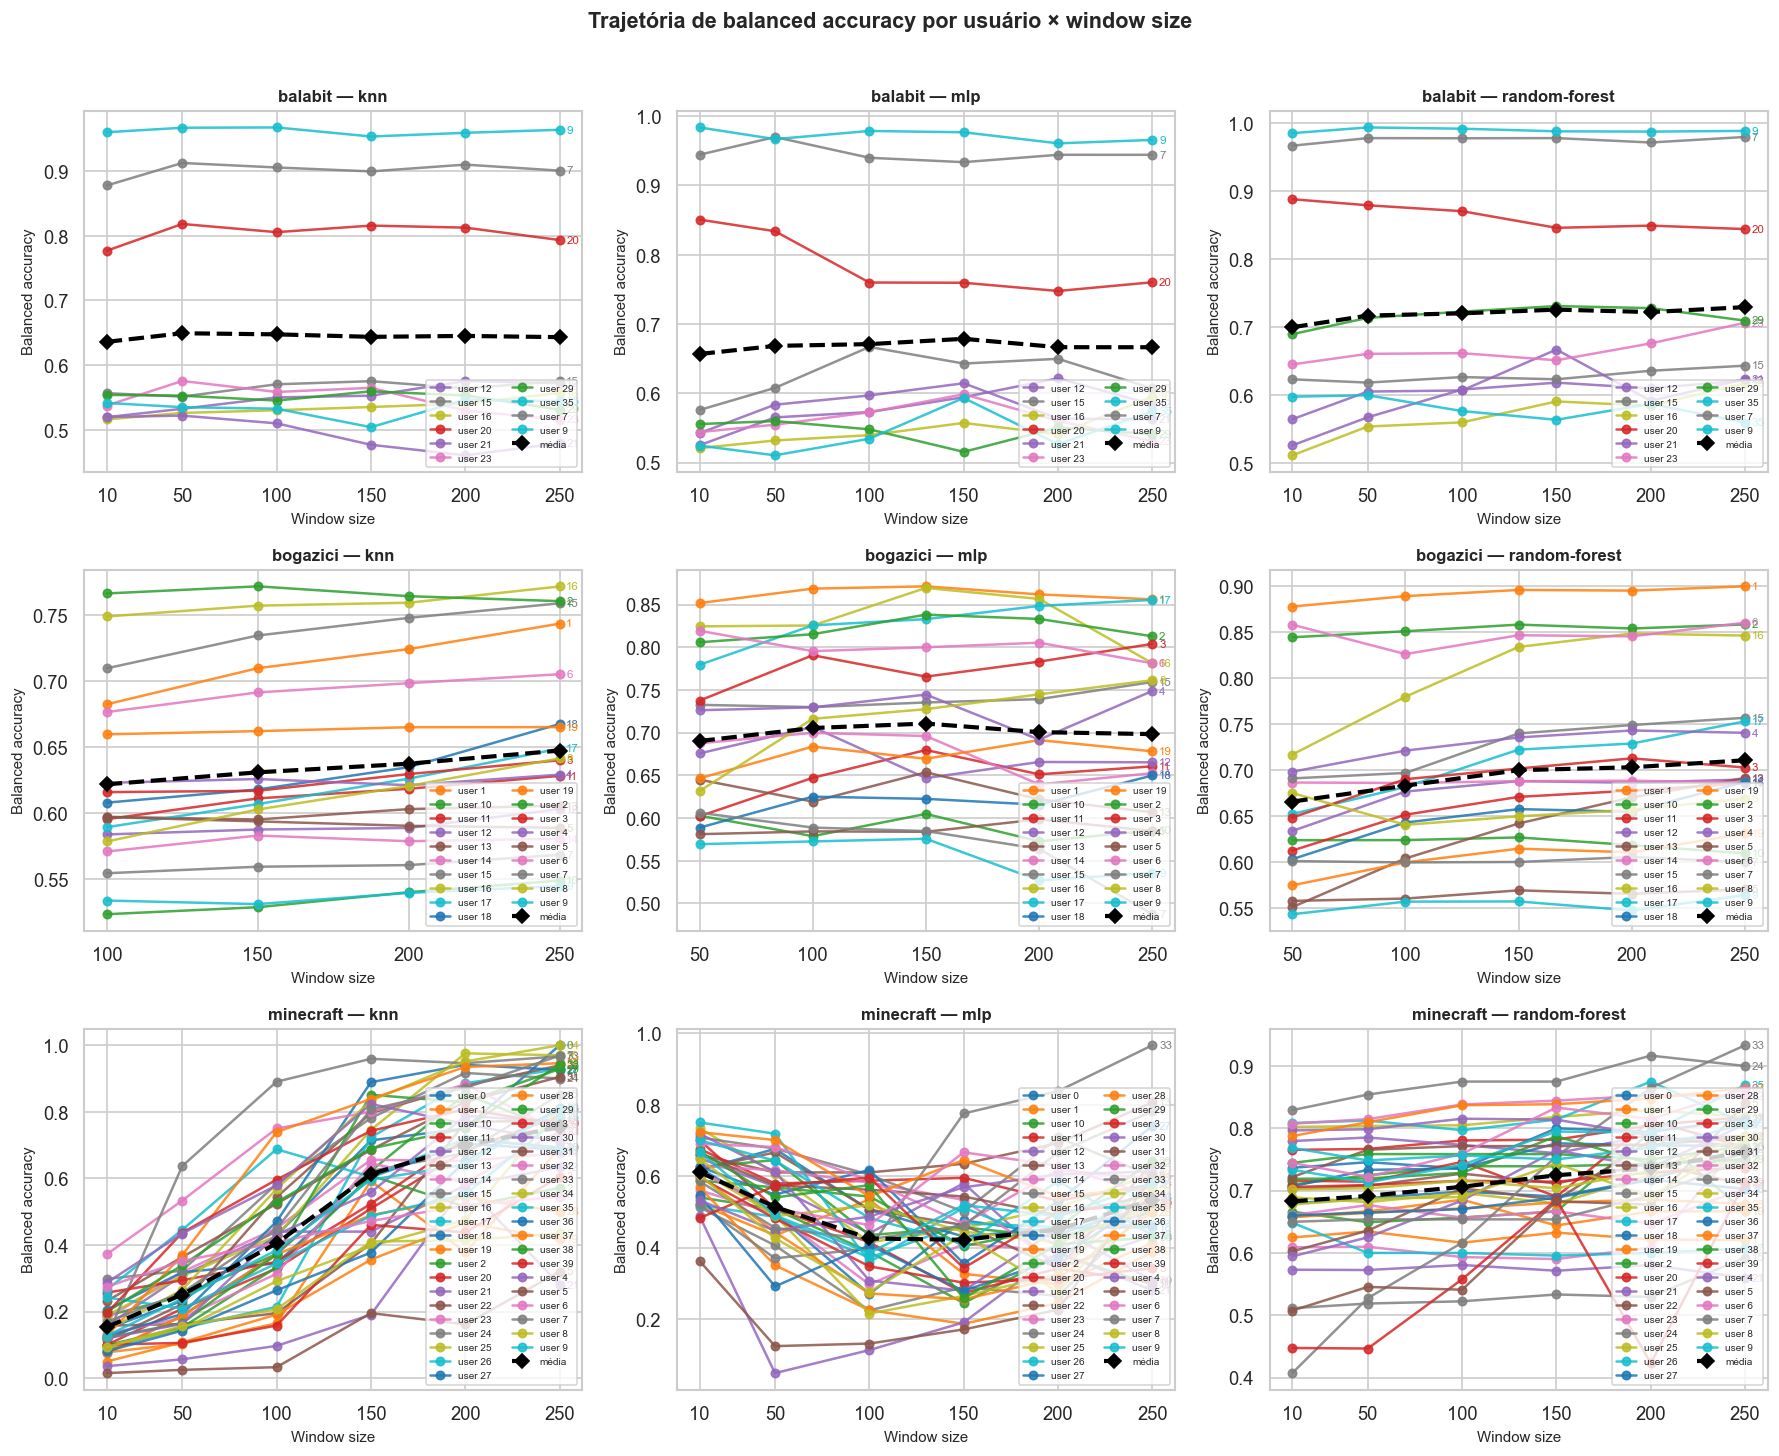

In [13]:
classifiers = sorted(df_ws['classifier'].unique())
datasets    = sorted(df_ws['dataset'].unique())

n_rows = len(datasets)
n_cols = len(classifiers)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
    sharey=False,
)

palette = sns.color_palette('tab10', n_colors=df_ws['user_id'].nunique())
user_colors = {uid: palette[i] for i, uid in enumerate(sorted(df_ws['user_id'].unique()))}

for row_idx, dataset in enumerate(datasets):
    for col_idx, clf in enumerate(classifiers):
        ax = axes[row_idx][col_idx]

        sub = df_ws[(df_ws['dataset'] == dataset) & (df_ws['classifier'] == clf)]

        if sub.empty:
            ax.set_visible(False)
            continue

        window_sizes = sorted(sub['window_size'].unique())

        for uid, grp in sub.groupby('user_id'):
            grp_sorted = grp.sort_values('window_size')
            ax.plot(
                grp_sorted['window_size'],
                grp_sorted['balanced_score'],
                marker='o',
                linewidth=1.5,
                markersize=5,
                color=user_colors[uid],
                label=f'user {uid}',
                alpha=0.85,
            )
            # Anota o user_id no último ponto
            last = grp_sorted.iloc[-1]
            ax.annotate(
                uid,
                (last['window_size'], last['balanced_score']),
                fontsize=7,
                xytext=(4, 0),
                textcoords='offset points',
                color=user_colors[uid],
                va='center',
            )

        # Média entre usuários
        mean_per_ws = sub.groupby('window_size')['balanced_score'].mean()
        ax.plot(
            mean_per_ws.index,
            mean_per_ws.values,
            color='black',
            linewidth=2.5,
            linestyle='--',
            marker='D',
            markersize=6,
            label='média',
            zorder=5,
        )

        ax.set_xticks(window_sizes)
        ax.set_title(f"{dataset} — {clf}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Window size", fontsize=9)
        ax.set_ylabel("Balanced accuracy", fontsize=9)
        ax.legend(fontsize=6, loc='lower right', ncol=2)

plt.suptitle(
    "Trajetória de balanced accuracy por usuário × window size",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('lineplot_window_size.png', bbox_inches='tight')
plt.show()

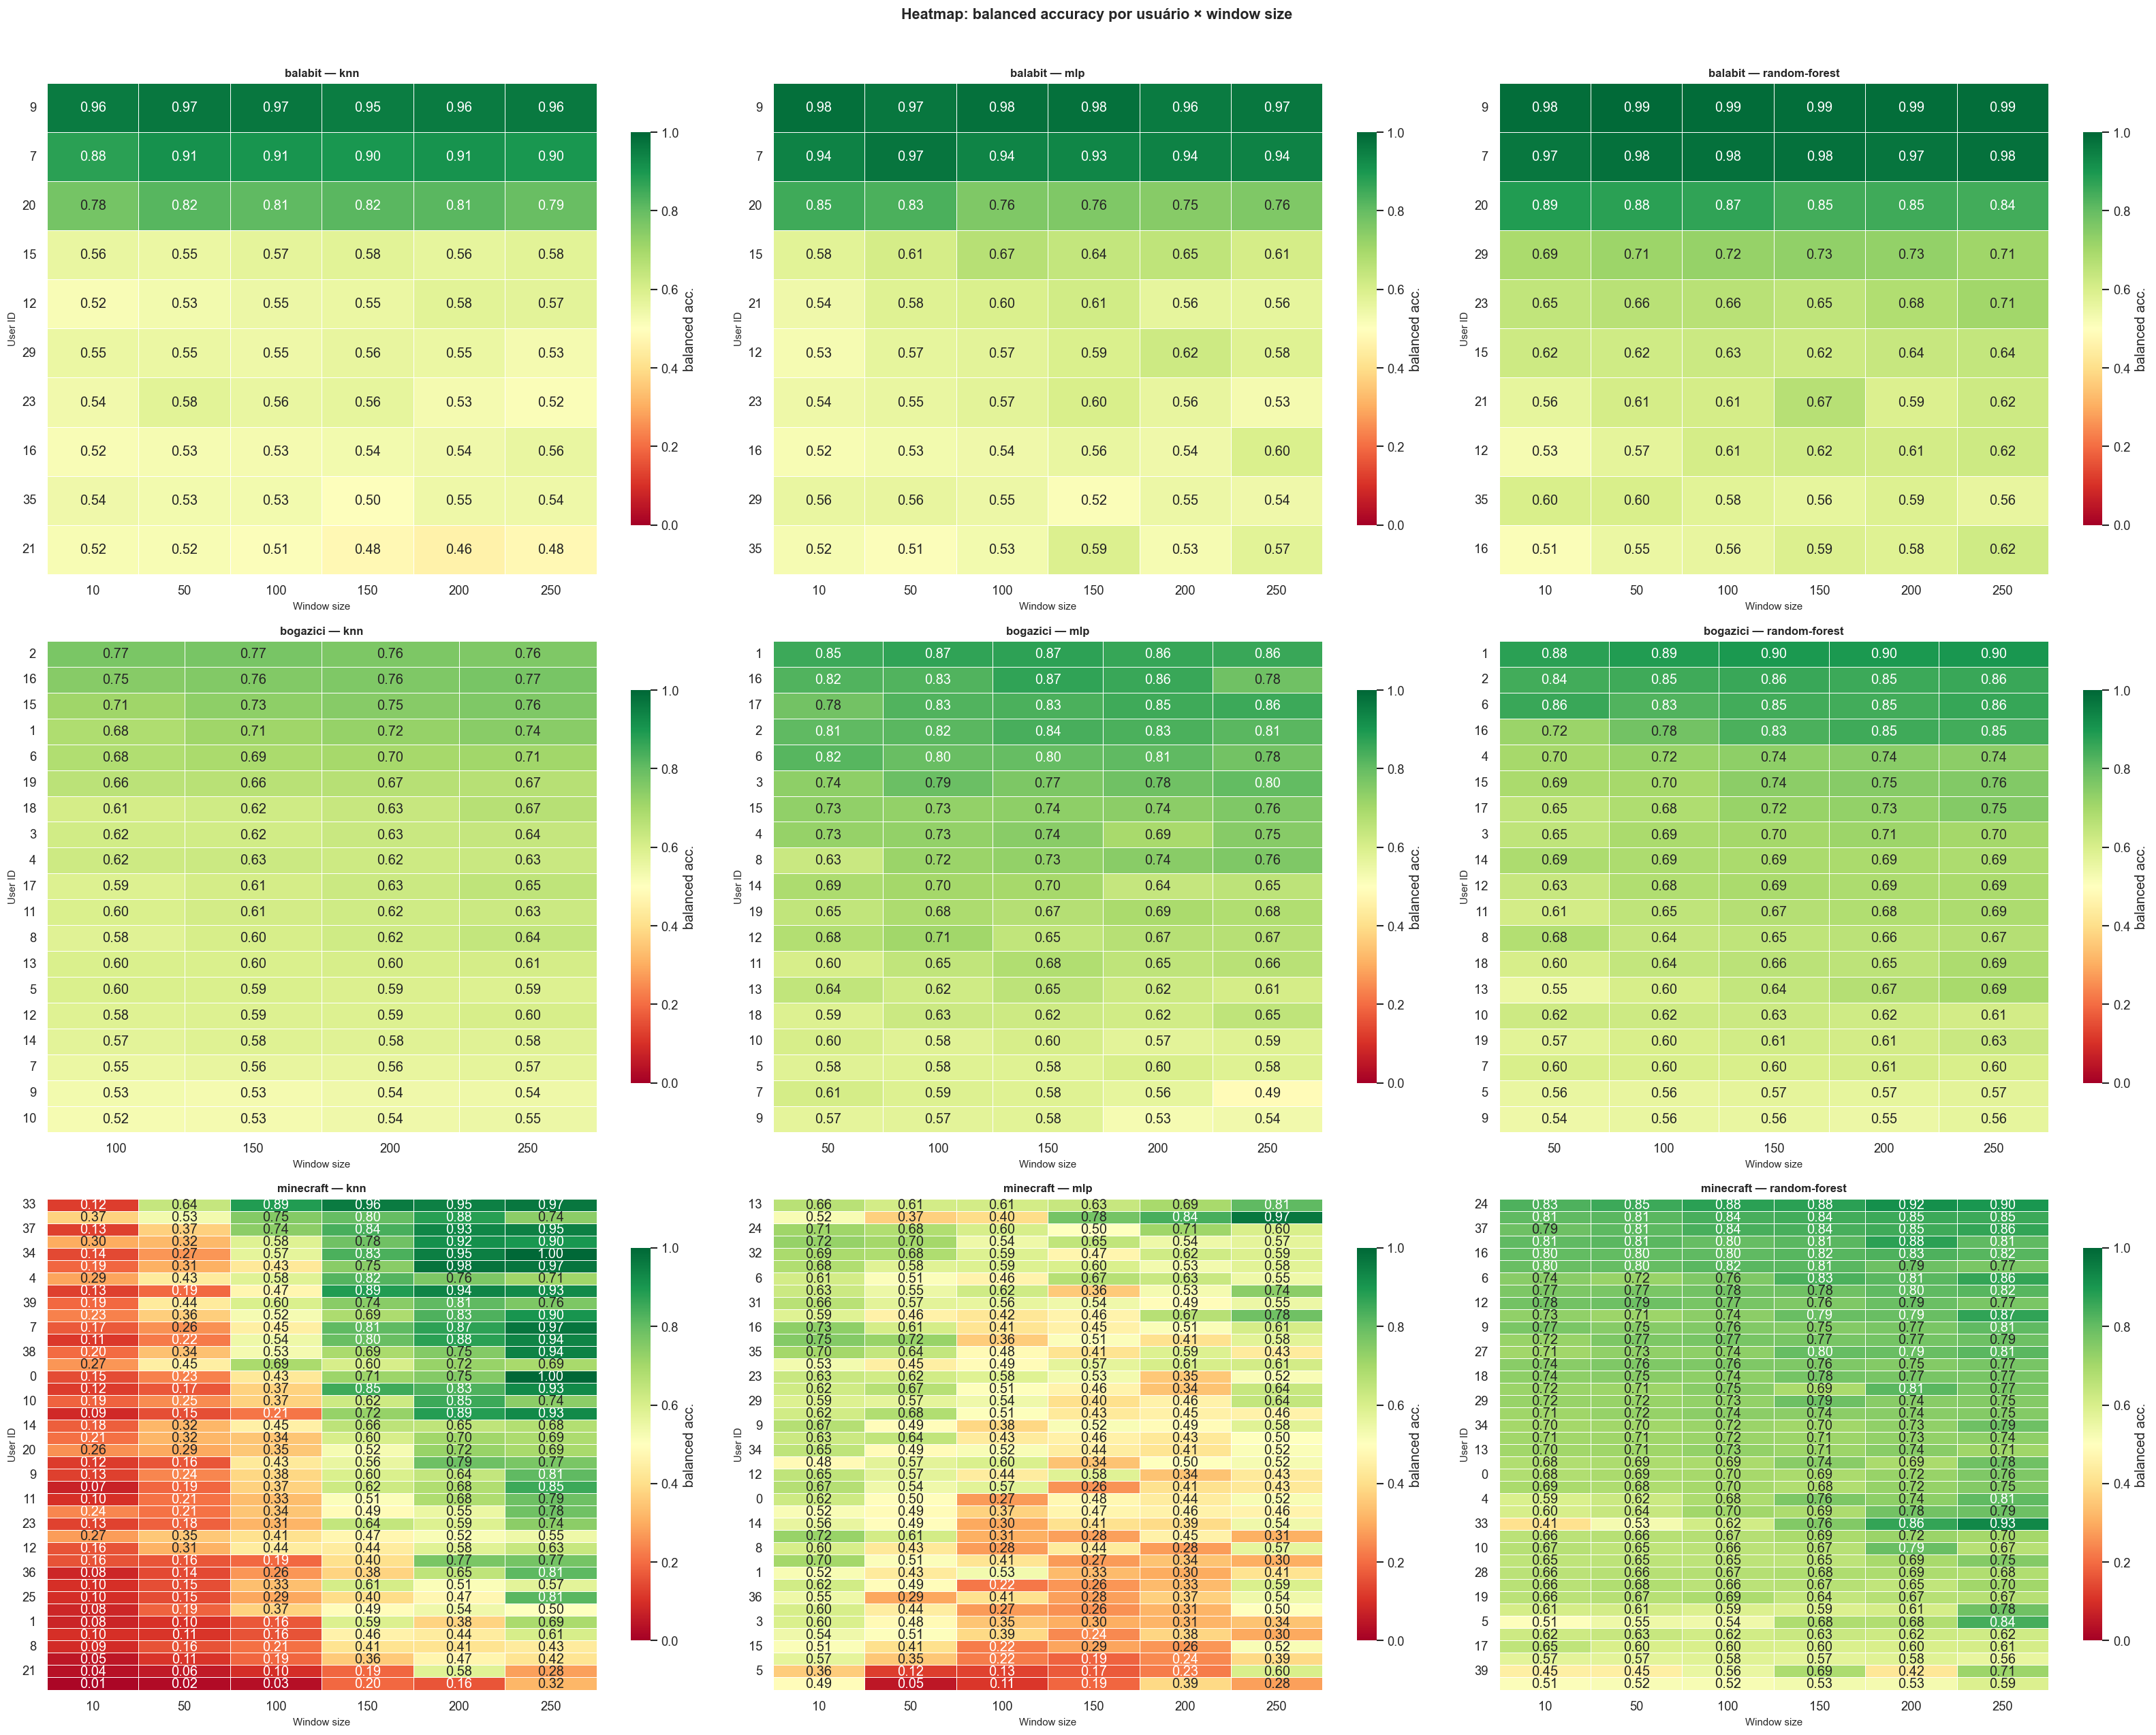

In [15]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(9 * n_cols, 7 * n_rows),
    squeeze=False,
)

for row_idx, dataset in enumerate(datasets):
    for col_idx, clf in enumerate(classifiers):
        ax = axes[row_idx][col_idx]

        sub = df_ws[(df_ws['dataset'] == dataset) & (df_ws['classifier'] == clf)]

        if sub.empty:
            ax.set_visible(False)
            continue

        pivot = (
            sub
            .pivot_table(index='user_id', columns='window_size', values='balanced_score')
            .sort_index()
        )

        # Ordena usuários pelo score médio (melhor no topo)
        pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap='RdYlGn',
            vmin=0.0,
            vmax=1.0,
            annot=True,
            fmt='.2f',
            linewidths=0.4,
            linecolor='white',
            cbar_kws={'shrink': 0.8,'label': 'balanced acc.'},
        )

        ax.set_title(f"{dataset} — {clf}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Window size", fontsize=9)
        ax.set_ylabel("User ID", fontsize=9)
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0)

plt.suptitle(
    "Heatmap: balanced accuracy por usuário × window size",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('heatmap_window_size.png', bbox_inches='tight')
plt.show()